In [1]:
!wget -O "data.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2026-05-07 14:01:00--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2026-05-07 14:01:00--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.70.197, 3.5.73.77, 3.5.68.118, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.70.197|:443... conne

In [2]:
!unzip /content/data.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [3]:

!pip install opendatasets

import opendatasets as od

od.download("https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: pradiptakhan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset


100%|██████████| 896M/896M [00:22<00:00, 41.4MB/s]


### Splitting `Plant_leave_diseases_dataset_with_augmentation`

I will now split the dataset located at `/content/Plant_leave_diseases_dataset_with_augmentation` into 80% training, 10% validation, and 10% test sets using the `split-folders` library. The output will be in a temporary directory called `temp_split_data`.

In [4]:
!pip install split-folders
import splitfolders

input_folder = '/content/Plant_leave_diseases_dataset_with_augmentation'
output_folder = 'temp_split_data'

# Split with a ratio. The ratio must be a tuple with (train, val, test) or (train, val) or (train, test)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.8, 0.1, 0.1), group_prefix=None)

Copying files: 61486 files [00:18, 3397.20 files/s]


### Merging datasets into `final_data`

Now, I will create the `final_data` directory structure and merge the newly split data with the existing `plantdoc-dataset`.

In [5]:
import os
import shutil

final_data_base = 'final_data'
output_folder = 'temp_split_data'
os.makedirs(os.path.join(final_data_base, 'train'), exist_ok=True)
os.makedirs(os.path.join(final_data_base, 'val'), exist_ok=True)
os.makedirs(os.path.join(final_data_base, 'test'), exist_ok=True)

# Define source directories
plantdoc_train = '/content/plantdoc-dataset/train'
plantdoc_test = '/content/plantdoc-dataset/test'
temp_split_train = os.path.join(output_folder, 'train')
temp_split_val = os.path.join(output_folder, 'val')
temp_split_test = os.path.join(output_folder, 'test')

# Function to move contents of a directory to another
def move_directory_contents(src, dst):
    if not os.path.exists(src):
        print(f"Source directory does not exist: {src}")
        return
    for item in os.listdir(src):
        s = os.path.join(src, item)
        d = os.path.join(dst, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)

# Merge train data
print("Merging training data...")
move_directory_contents(plantdoc_train, os.path.join(final_data_base, 'train'))
move_directory_contents(temp_split_train, os.path.join(final_data_base, 'train'))

# Merge test data
print("Merging test data...")
move_directory_contents(plantdoc_test, os.path.join(final_data_base, 'test'))
move_directory_contents(temp_split_test, os.path.join(final_data_base, 'test'))

# Move validation data
print("Moving validation data...")
move_directory_contents(temp_split_val, os.path.join(final_data_base, 'val'))

print("Data merging complete. Final structure in 'final_data'.")

Merging training data...
Merging test data...
Moving validation data...
Data merging complete. Final structure in 'final_data'.


You can now find the merged and split datasets in the `final_data` directory, organized into `train`, `val`, and `test` subdirectories.

### Data Count Verification

Let's verify the data counts in the merged `final_data` directory and compare them with the original datasets before merging.

In [6]:
def count_files_in_directory(path):
    if not os.path.exists(path):
        return 0
    count = 0
    for root, _, files in os.walk(path):
        count += len(files)
    return count

# Count files in final_data and its subdirectories
print("\n--- Final Data Counts ---")
final_train_count = count_files_in_directory(os.path.join(final_data_base, 'train'))
final_val_count = count_files_in_directory(os.path.join(final_data_base, 'val'))
final_test_count = count_files_in_directory(os.path.join(final_data_base, 'test'))

print(f"Final Train data count: {final_train_count}")
print(f"Final Validation data count: {final_val_count}")
print(f"Final Test data count: {final_test_count}")
print(f"Total Final data count: {final_train_count + final_val_count + final_test_count}")

# Count files in original datasets
print("\n--- Original Data Counts Before Merging ---")
plantdoc_train_orig_count = count_files_in_directory(plantdoc_train)
plantdoc_test_orig_count = count_files_in_directory(plantdoc_test)
plant_leave_diseases_orig_count = count_files_in_directory(input_folder)

print(f"Original PlantDoc dataset (train) count: {plantdoc_train_orig_count}")
print(f"Original PlantDoc dataset (test) count: {plantdoc_test_orig_count}")
print(f"Original Plant_leave_diseases_dataset_with_augmentation count: {plant_leave_diseases_orig_count}")


--- Final Data Counts ---
Final Train data count: 51849
Final Validation data count: 6139
Final Test data count: 6420
Total Final data count: 64408

--- Original Data Counts Before Merging ---
Original PlantDoc dataset (train) count: 2670
Original PlantDoc dataset (test) count: 252
Original Plant_leave_diseases_dataset_with_augmentation count: 61486


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

# **Data Pre-Processing**

In [8]:
train_dir = "/content/final_data/train"
validation_dir = "/content/final_data/val"
test_dir="/content/final_data/test"

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)
test_dataset=tf.keras.utils.image_dataset_from_directory(test_dir,
                                                         shuffle=True,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMG_SIZE)


Found 51849 files belonging to 67 classes.
Found 6139 files belonging to 39 classes.
Found 6420 files belonging to 66 classes.


# Fixing Class Mismatched Problem

In [9]:
# Manually defined renaming map to unify class names
# Prioritize names with '___' as canonical, and map simpler/different versions to them.
renaming_map = {
    'Apple_Scab_Leaf': 'Apple___Apple_scab',
    'apple scab': 'Apple___Apple_scab',
    'apple black rot': 'Apple___Black_rot',
    'apple rust': 'Apple___Cedar_apple_rust',
    'healthy apple': 'Apple___healthy',
    'Apple_leaf': 'Apple___healthy', # Assuming 'Apple_leaf' implies healthy
    'Apple_rust_leaf': 'Apple___Cedar_apple_rust',

    'Blueberry_leaf': 'Blueberry___healthy',

    'Cherry_leaf': 'Cherry___healthy',

    'Corn_Gray_leaf_spot': 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn common rust': 'Corn___Common_rust',
    'Corn_leaf_blight': 'Corn___Northern_Leaf_Blight', # Best guess based on common diseases
    'Corn_rust_leaf': 'Corn___Common_rust', # Best guess

    'grape black rot': 'Grape___Black_rot',
    'healthy grape': 'Grape___healthy',

    'Peach_leaf': 'Peach___healthy',

    'Bell_pepper_leaf': 'Pepper,_bell___healthy',
    'Bell_pepper_leaf_spot': 'Pepper,_bell___Bacterial_spot', # Assuming 'spot' implies bacterial spot

    'Potato_leaf_early_blight': 'Potato___Early_blight',
    'Potato_leaf_late_blight': 'Potato___Late_blight',
    'healthy potato': 'Potato___healthy',

    'Raspberry_leaf': 'Raspberry___healthy',

    'Soyabean_leaf': 'Soybean___healthy',

    'Squash_Powdery_mildew_leaf': 'Squash___Powdery_mildew',

    'Strawberry_leaf': 'Strawberry___healthy',

    'Tomato_Early_blight_leaf': 'Tomato___Early_blight',
    'Tomato_Septoria_leaf_spot': 'Tomato___Septoria_leaf_spot',
    'healthy tomato': 'Tomato___healthy',
    'tomato late blight': 'Tomato___Late_blight',
    'tomato leaf mold': 'Tomato___Leaf_Mold',
    'tomato septoria leaf spot': 'Tomato___Septoria_leaf_spot',
}

def unify_class_names_in_directory_structure(base_dir, renaming_map):
    print(f"Starting to unify class names in: {base_dir}")
    for split_type in ['train', 'val', 'test']:
        split_path = os.path.join(base_dir, split_type)
        if not os.path.exists(split_path):
            print(f"  Warning: {split_path} does not exist. Skipping.")
            continue

        print(f"  Processing split: {split_type}")
        for class_folder_name in os.listdir(split_path):
            current_path = os.path.join(split_path, class_folder_name)
            if os.path.isdir(current_path):
                if class_folder_name in renaming_map:
                    new_name = renaming_map[class_folder_name]
                    new_path = os.path.join(split_path, new_name)
                    if current_path != new_path: # Avoid renaming to self
                        print(f"    Renaming '{class_folder_name}' to '{new_name}' in {split_type}")
                        # If the new_path already exists (due to another renamed folder or original),
                        # we need to move contents. Otherwise, just rename.
                        if os.path.exists(new_path):
                            print(f"      Destination '{new_path}' already exists. Merging contents.")
                            for item in os.listdir(current_path):
                                src_item_path = os.path.join(current_path, item)
                                dst_item_path = os.path.join(new_path, item)
                                if os.path.isdir(src_item_path):
                                    shutil.copytree(src_item_path, dst_item_path, dirs_exist_ok=True)
                                else:
                                    shutil.copy2(src_item_path, dst_item_path)
                            shutil.rmtree(current_path) # Remove the original folder after merging
                        else:
                            os.rename(current_path, new_path)
    print("Class name unification complete.")

# Call the function to unify names
unify_class_names_in_directory_structure(final_data_base, renaming_map)

# After renaming, regenerate the sorted_class_names from the unified structure
all_class_names_unified = set()
for split_dir in [os.path.join(final_data_base, 'train'), os.path.join(final_data_base, 'val'), os.path.join(final_data_base, 'test')]:
    if os.path.exists(split_dir):
        for class_name in os.listdir(split_dir):
            if os.path.isdir(os.path.join(split_dir, class_name)):
                all_class_names_unified.add(class_name)
sorted_class_names = sorted(list(all_class_names_unified))

print(f"\nUnified class names after renaming: {len(sorted_class_names)}")
print(f"First 10 unified class names: {sorted_class_names[:10]}")

Starting to unify class names in: final_data
  Processing split: train
    Renaming 'Blueberry_leaf' to 'Blueberry___healthy' in train
      Destination 'final_data/train/Blueberry___healthy' already exists. Merging contents.
    Renaming 'Apple_leaf' to 'Apple___healthy' in train
      Destination 'final_data/train/Apple___healthy' already exists. Merging contents.
    Renaming 'Soyabean_leaf' to 'Soybean___healthy' in train
      Destination 'final_data/train/Soybean___healthy' already exists. Merging contents.
    Renaming 'Corn_Gray_leaf_spot' to 'Corn___Cercospora_leaf_spot Gray_leaf_spot' in train
      Destination 'final_data/train/Corn___Cercospora_leaf_spot Gray_leaf_spot' already exists. Merging contents.
    Renaming 'Potato_leaf_late_blight' to 'Potato___Late_blight' in train
      Destination 'final_data/train/Potato___Late_blight' already exists. Merging contents.
    Renaming 'Squash_Powdery_mildew_leaf' to 'Squash___Powdery_mildew' in train
      Destination 'final_data

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 51849 files belonging to 48 classes.


In [11]:
# Before creating validation_dataset, ensure all class directories from train_dataset exist in validation_dir
for class_name in train_dataset.class_names:
    class_path = os.path.join(validation_dir, class_name)
    os.makedirs(class_path, exist_ok=True)

validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                 class_names=train_dataset.class_names)

Found 6139 files belonging to 48 classes.


In [12]:
# Before creating test_dataset, ensure all class directories from train_dataset exist in test_dir
for class_name in train_dataset.class_names:
    class_path = os.path.join(test_dir, class_name)
    os.makedirs(class_path, exist_ok=True)

test_dataset=tf.keras.utils.image_dataset_from_directory(test_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMG_SIZE,
                                                         class_names=train_dataset.class_names)

Found 6420 files belonging to 48 classes.


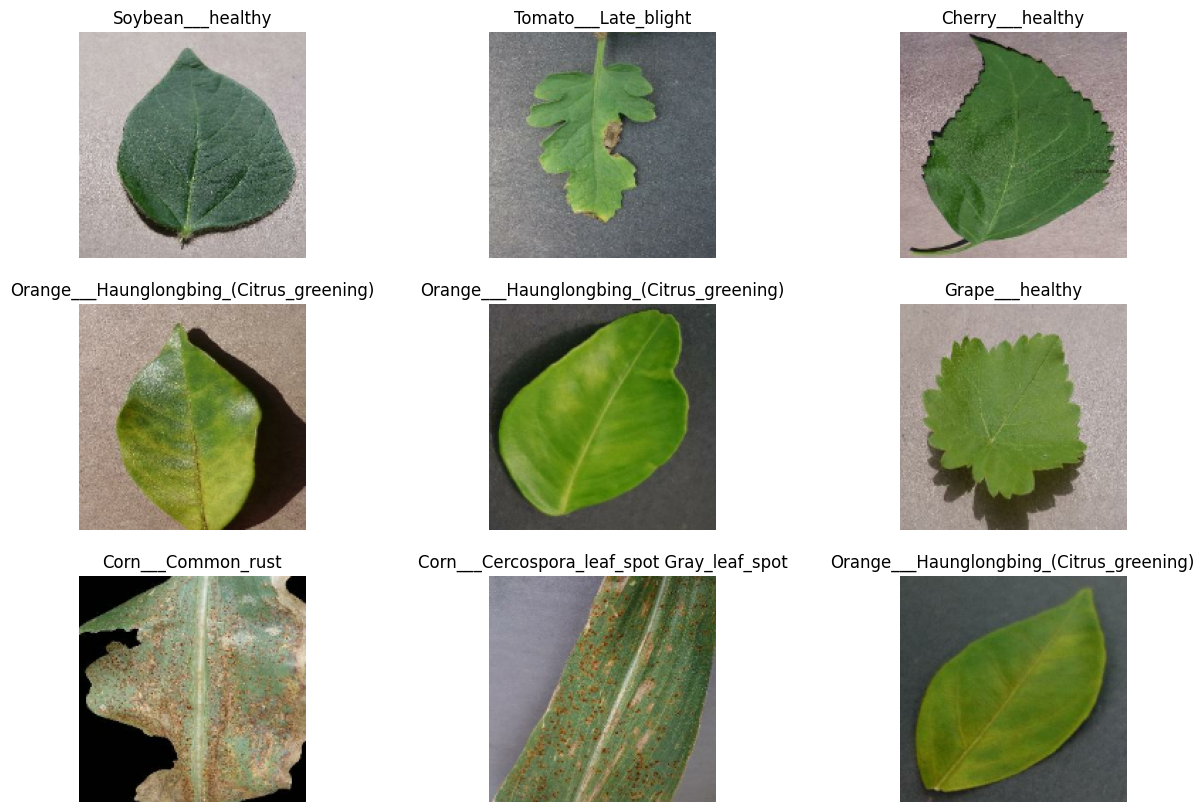

In [13]:
class_names = train_dataset.class_names

plt.figure(figsize=(15, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [14]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Background_without_leaves',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot'

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Rescale Pixel Value

In [16]:
preprocess_input =  tf.keras.applications.efficientnet.preprocess_input

# Create the base model from the pre-trained convnets

In [17]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.EfficientNetB7(
                                          input_shape=IMG_SHAPE,
                                          include_top=False,
                                          weights='imagenet'
                                      )

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [18]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 2560)


## Feature extraction

Freeze the convolutional base

In [19]:
base_model.trainable = False

In [20]:
base_model.summary()


Model: "efficientnetb7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 160, 160,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 160, 160,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │      1,728 │ stem_conv_pad[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        576 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        256 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 64)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 64)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 16)  │      1,040 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 64)  │      1,088 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 64)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │      2,048 │ block1a_se_excit

 Total params: 64,097,687 (244.51 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 64,097,687 (244.51 MB)

In [21]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 2560)


In [22]:
prediction_layer = tf.keras.layers.Dense(len(class_names), activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 48)


In [23]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb7 (Functional)     │ (None, 5, 5, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │       122,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,220,615 (244.98 MB)

 Trainable params: 122,928 (480.19 KB)

 Non-trainable params: 64,097,687 (244.51 MB)

In [25]:
len(model.trainable_variables)

2

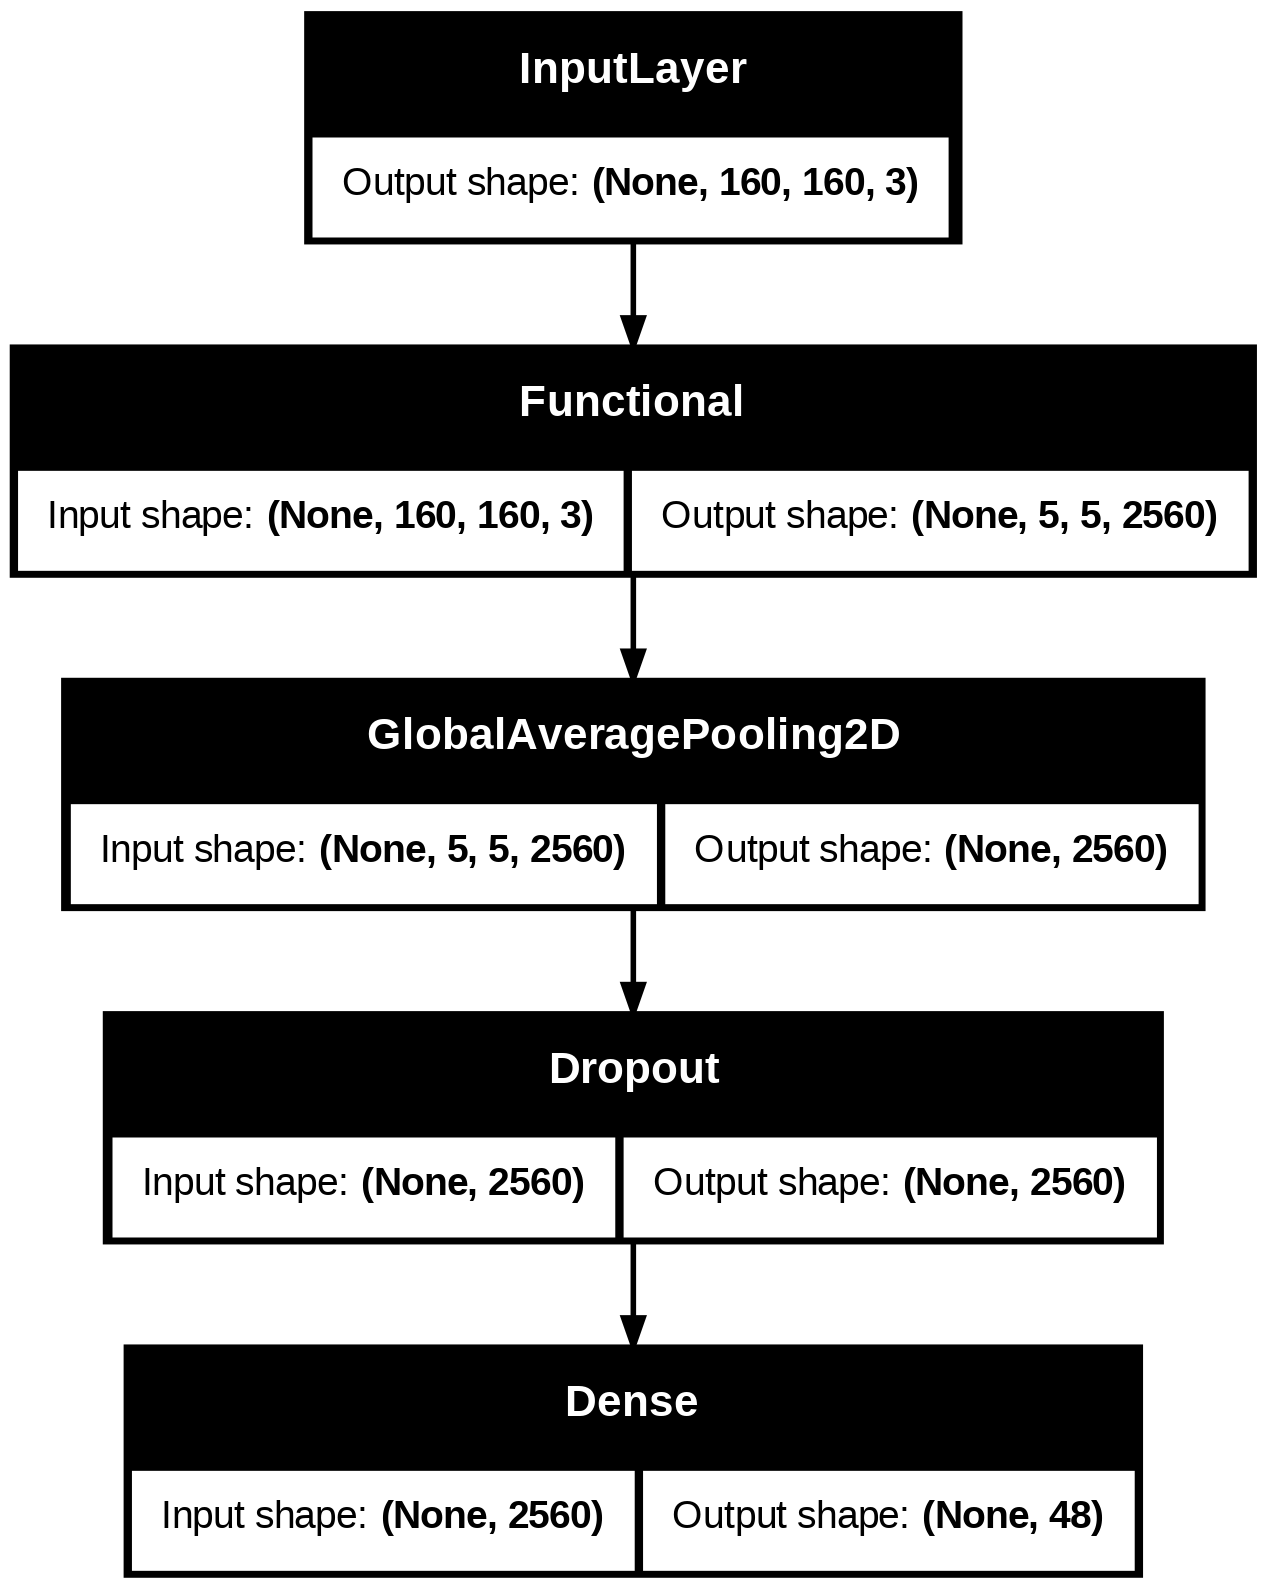

In [26]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [27]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [28]:
initial_epochs = 6

loss0, accuracy0 = model.evaluate(validation_dataset)

192/192 ━━━━━━━━━━━━━━━━━━━━ 78s 235ms/step - accuracy: 0.0252 - loss: 3.8743


In [29]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 3.87
initial accuracy: 0.03


In [30]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/6
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 375s 185ms/step - accuracy: 0.7825 - loss: 0.8662 - val_accuracy: 0.9018 - val_loss: 0.3631
Epoch 2/6
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 252s 156ms/step - accuracy: 0.8810 - loss: 0.4372 - val_accuracy: 0.9264 - val_loss: 0.2599
Epoch 3/6
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 259s 160ms/step - accuracy: 0.8970 - loss: 0.3595 - val_accuracy: 0.9374 - val_loss: 0.2201
Epoch 4/6
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 278s 170ms/step - accuracy: 0.9083 - loss: 0.3171 - val_accuracy: 0.9389 - val_loss: 0.2030
Epoch 5/6
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 263s 162ms/step - accuracy: 0.9142 - loss: 0.2894 - val_accuracy: 0.9477 - val_loss: 0.1829
Epoch 6/6
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 321s 161ms/step - accuracy: 0.9182 - loss: 0.2715 - val_accuracy: 0.9459 - val_loss: 0.1771


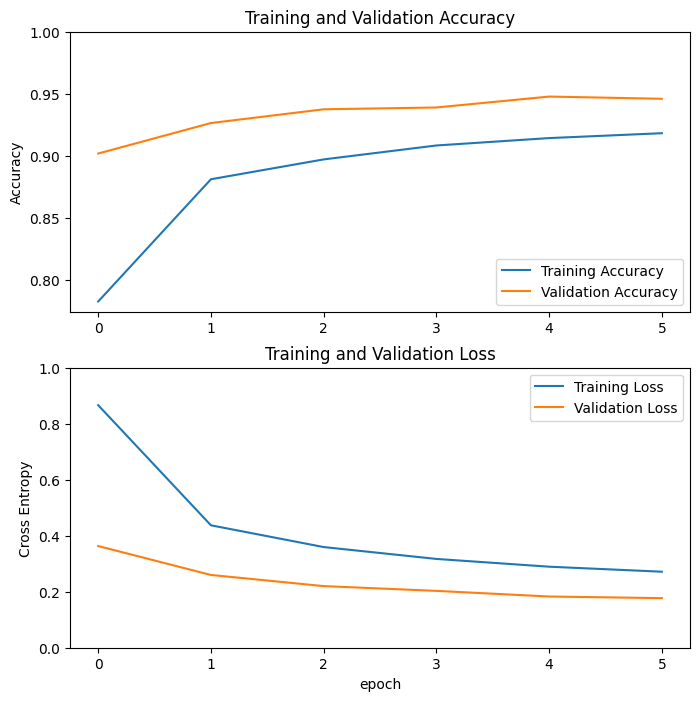

In [31]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

# Fine Tuning

In [32]:
base_model.trainable = True

In [33]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  814


In [34]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [35]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb7 (Functional)     │ (None, 5, 5, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │       122,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,220,615 (244.98 MB)

 Trainable params: 63,784,088 (243.32 MB)

 Non-trainable params: 436,527 (1.67 MB)

In [36]:
len(model.trainable_variables)

626

In [39]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 7/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 929s 573ms/step - accuracy: 0.9128 - loss: 0.2992 - val_accuracy: 0.9137 - val_loss: 0.7097
Epoch 8/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 760s 469ms/step - accuracy: 0.9467 - loss: 0.1732 - val_accuracy: 0.9728 - val_loss: 0.0926
Epoch 9/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 765s 472ms/step - accuracy: 0.9561 - loss: 0.1410 - val_accuracy: 0.9658 - val_loss: 0.1180
Epoch 10/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 767s 473ms/step - accuracy: 0.9617 - loss: 0.1196 - val_accuracy: 0.9555 - val_loss: 0.1311
Epoch 11/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 767s 473ms/step - accuracy: 0.9657 - loss: 0.1047 - val_accuracy: 0.9754 - val_loss: 0.0648
Epoch 12/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 767s 473ms/step - accuracy: 0.9720 - loss: 0.0848 - val_accuracy: 0.9858 - val_loss: 0.0410
Epoch 13/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 766s 473ms/step - accuracy: 0.9728 - loss: 0.0775 - val_accuracy: 0.9777 - val_loss: 0.0548
Epoch 14/16
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 812s 479ms/step

In [40]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

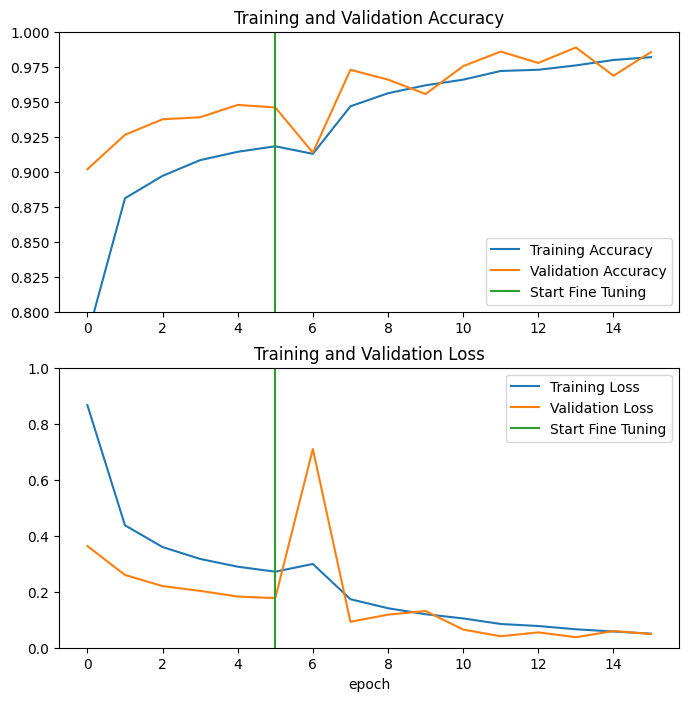

In [41]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

# Evaluation_and_prediction

In [42]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 238ms/step - accuracy: 0.9642 - loss: 0.1661
Test accuracy : 0.9641744494438171


In [44]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)
predictions = tf.argmax(predictions, axis=1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)



Predictions:
 [38  2 38  6 16  8 37 25 18 10 30  2  7 31 35 43 36  8 13 25 21 29 31 19
  5 37 36 44 36  0 33 25]
Labels:
 [38  2 38  6 16  8 37 25 18 10 30  2  7 31 35 43 36  8 13 25 30 29 31 19
  5 37 36  2 36  0 44 25]


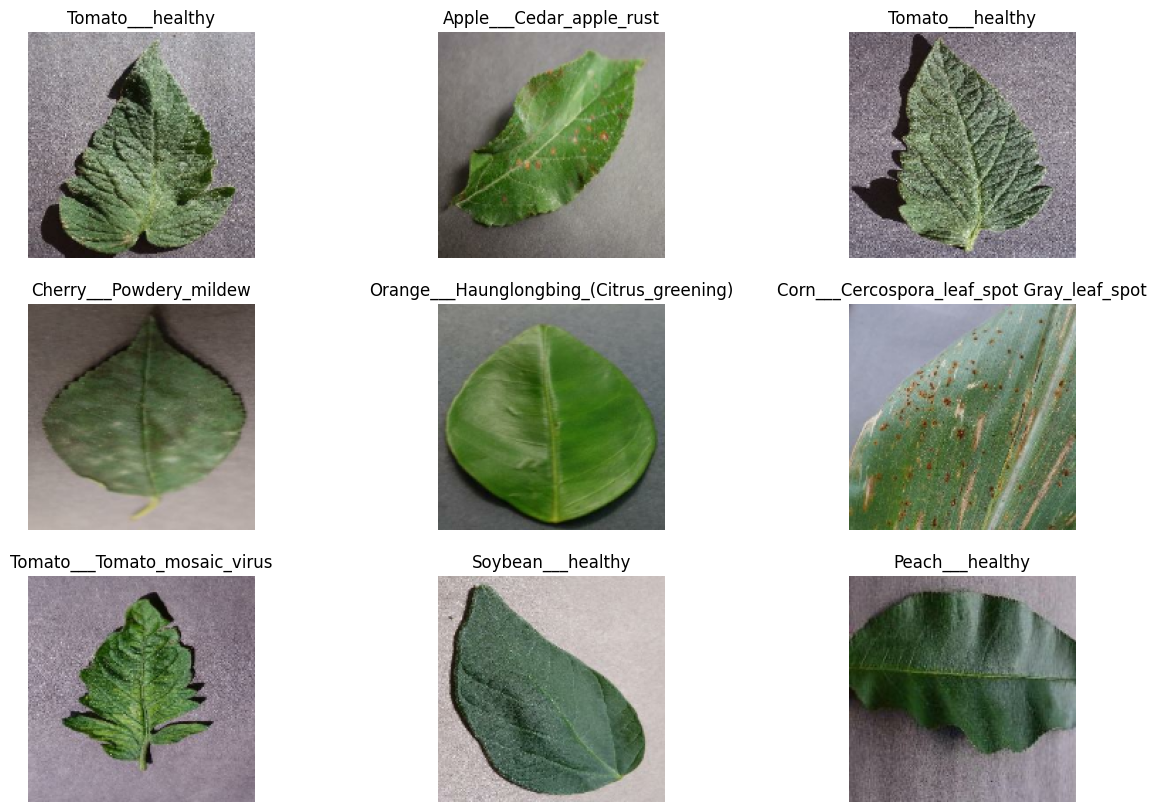

In [45]:
plt.figure(figsize=(15, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

# Saving the Model

In [46]:
model.save("plant_disease_recog_model.keras")

In [47]:
model.save("/content/drive/MyDrive/plant_disease_recog_model.keras")